In [12]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler

In [2]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_train.csv"
TEST_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_test.csv"

In [3]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.219595,0.267058,2.972050,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,0.154822,0.006604,0.000495,0.059292,0.002836,0.052960,13.772706,101.000067,No Anomaly,0.0
1,0.028225,0.042124,1.432100,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,0.229541,0.005869,0.000024,0.086108,0.003364,0.161704,5.272073,27.131990,No Anomaly,0.0
2,0.214053,0.259569,2.228980,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,0.204520,0.014483,0.000405,0.238396,0.004220,0.210480,47.116885,38.577988,No Anomaly,0.0
3,0.255422,0.294430,2.998710,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,0.145544,0.006640,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,No Anomaly,0.0
4,0.081667,0.129274,1.561180,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,0.280788,0.004654,0.000065,0.076840,0.004868,0.389792,7.142787,32.665876,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34436,0.028173,0.041713,0.850848,0.745430,70.8238,25.2266,233.644,32.9921,274.601339,0.022594,...,0.419135,0.005320,0.000031,0.033940,0.004332,0.356680,6.444470,34.806232,No Anomaly,0.0
34437,0.080816,0.127709,1.614570,1.061416,87.1087,22.1432,230.259,76.9806,142.613204,0.013788,...,0.275657,0.006633,0.000120,0.088008,0.002244,0.425900,23.359892,73.578876,No Anomaly,0.0
34438,0.027668,0.041262,1.407610,1.401284,69.1150,24.8253,238.183,32.0000,169.210932,0.043790,...,0.242527,0.005921,0.000027,0.118400,0.004124,0.357284,10.415008,42.637613,No Anomaly,0.0
34439,0.209388,0.262548,2.756810,1.074847,88.4803,29.5671,235.927,127.6810,85.579710,0.008418,...,0.160045,0.007023,0.000280,0.041504,0.002468,0.265360,53.116416,18.142574,No Anomaly,0.0


In [4]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
dataframe_test

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.658640,1.074847,88.6217,29.3147,230.091,126.6770,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.814120,0.745430,68.0318,24.2354,232.174,32.0000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.810610,1.073357,68.8750,24.7075,208.422,32.0000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.125930,1.073357,68.9973,24.7679,235.556,27.0000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.654510,1.402774,90.2739,27.8473,225.678,123.6680,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,0.027119,0.039793,1.145980,1.073357,69.6155,24.9792,230.324,31.0000,200.984310,0.034624,...,0.310292,0.005538,0.000017,0.051492,0.003720,0.312968,18.169994,43.781339,Inlet Valve Malfunction,12.0
7377,0.209236,0.261347,2.532400,1.074847,88.9830,29.1743,222.902,126.0000,88.020060,0.008531,...,0.185456,0.007866,0.000314,0.162908,0.003280,0.386440,39.007200,33.850955,No Anomaly,0.0
7378,0.027496,0.039704,0.618982,1.073357,68.3109,24.4975,229.008,32.0317,369.975217,0.033509,...,0.566947,0.010855,0.000030,0.093068,0.004288,0.376272,7.216541,31.761236,No Anomaly,0.0
7379,0.243079,0.287370,2.320710,1.402774,85.5501,29.4859,250.139,127.3840,107.785548,0.011012,...,0.173380,0.010766,0.001260,0.094164,0.005896,0.459960,39.482278,107.722079,No Anomaly,0.0


In [5]:
X_train = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [18]:
y_train_bin = label_binarize(y_train, classes=np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

n_classes = y_train_bin.shape[1]

In [6]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [7]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_roc_auc_seaborn(y_test_bin, y_score, model_name):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = y_test_bin.shape[1]
    classes = range(n_classes)
    # Calculate ROC for each class
    for i in classes:
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)
    # Seaborn style
    sns.set(style='whitegrid')
    plt.figure(figsize=(10, 7))
    for i in classes:
        sns.lineplot(x=fpr[i], y=tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
    sns.lineplot(x=all_fpr, y=mean_tpr, label=f"Macro-average (AUC={roc_auc['macro']:.2f})", color="navy", linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f"ROC AUC - {model_name} (Seaborn)")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

def plot_pr_auc_seaborn(y_test_bin, y_score, model_name):
    precision = dict()
    recall = dict()
    pr_auc = dict()
    n_classes = y_test_bin.shape[1]
    classes = range(n_classes)
    for i in classes:
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        pr_auc[i] = auc(recall[i], precision[i])
    average_precision = average_precision_score(y_test_bin, y_score, average="macro")
    sns.set(style='whitegrid')
    plt.figure(figsize=(10, 7))
    for i in classes:
        sns.lineplot(x=recall[i], y=precision[i], label=f'Class {i} (AUC={pr_auc[i]:.2f})')
    plt.plot([0, 1], [0.5, 0.5], 'k--', lw=1)
    plt.title(f"Precision-Recall AUC - {model_name} (macro={average_precision:.2f}) (Seaborn)")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [9]:
results = {}

### Logistic Regression

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(solver='lbfgs', multi_class='ovr', C=5)

param_grid = {'C': [0.1, 1, 10]}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["Logistic Regression"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 3 candidates, totalling 9 fits


In [23]:
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


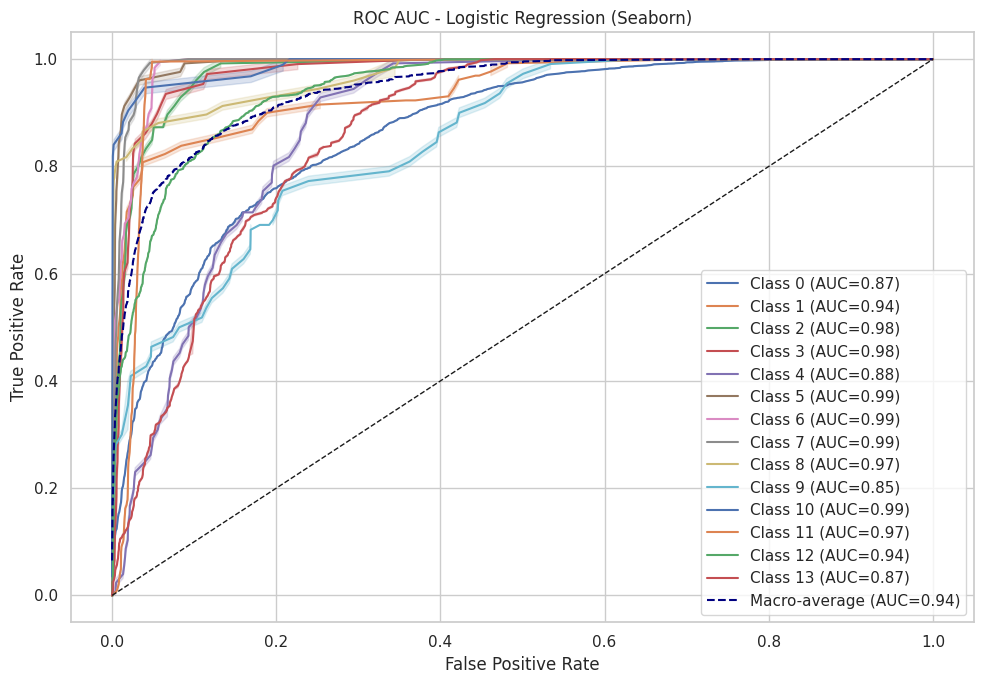

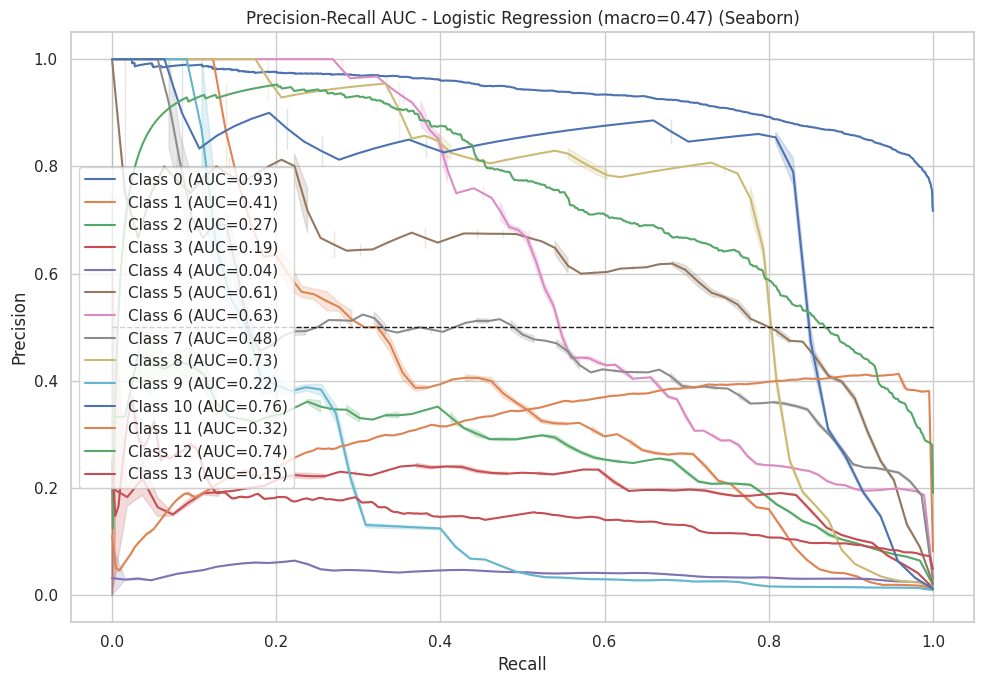

In [ ]:
y_score = results["Logistic Regression"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "Logistic Regression")
plot_pr_auc_seaborn(y_test_bin, y_score, "Logistic Regression")

### SVM

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True)

param_grid = {'C': [0.1, 1, 10]}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["SVM"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 3 candidates, totalling 9 fits


In [28]:
best_model

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


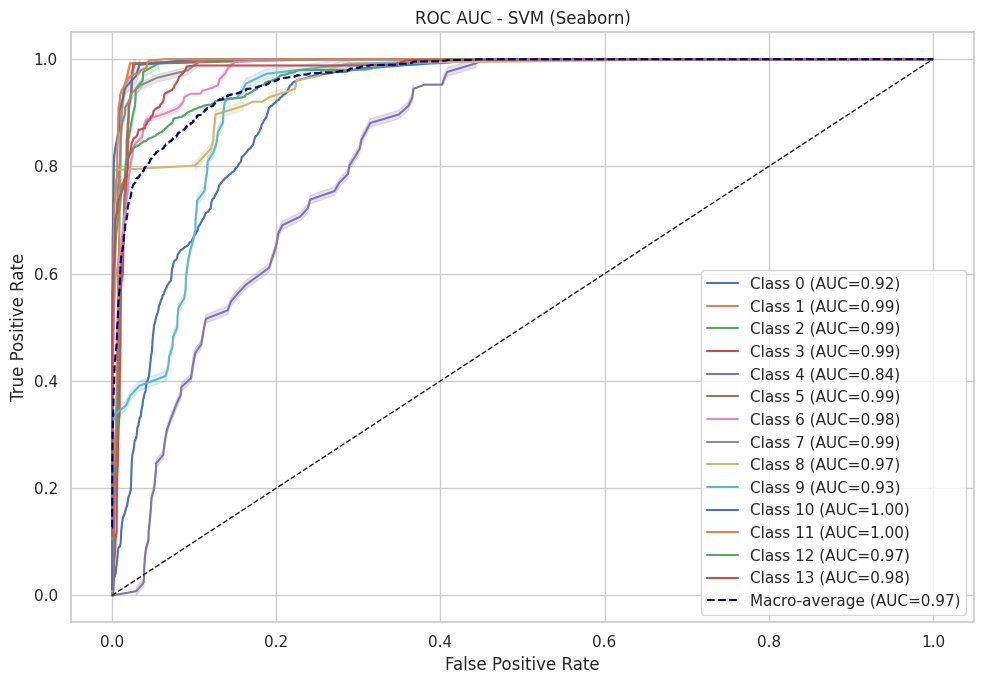

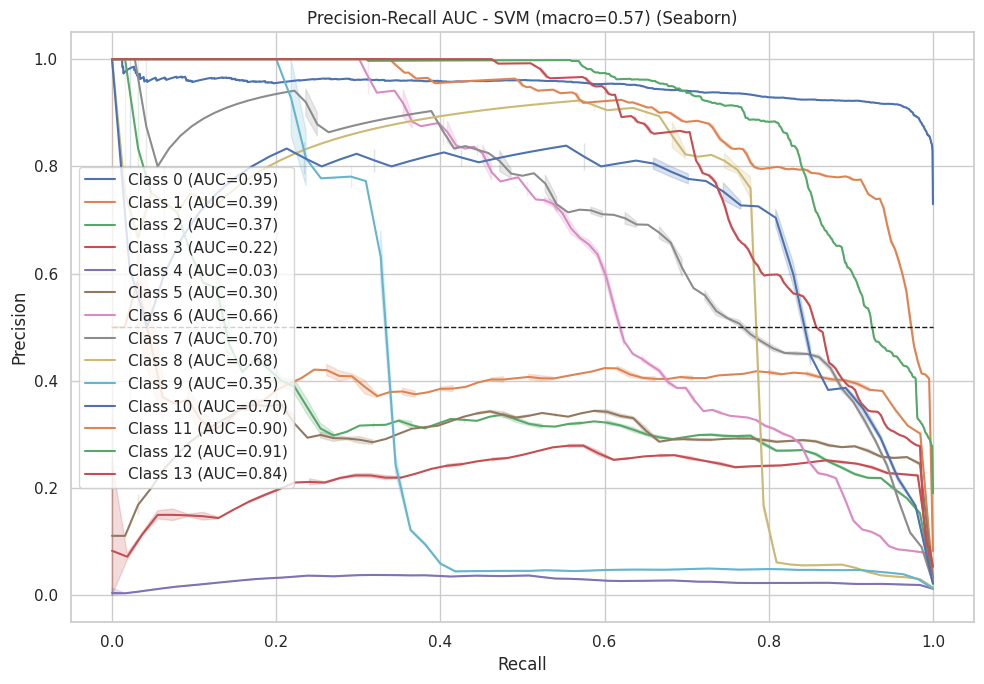

In [29]:
y_score = results["SVM"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "SVM")
plot_pr_auc_seaborn(y_test_bin, y_score, "SVM")

### Random Forest Classifier

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(random_state=SEED)

param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["Random Forest"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 6 candidates, totalling 18 fits


In [31]:
best_model

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


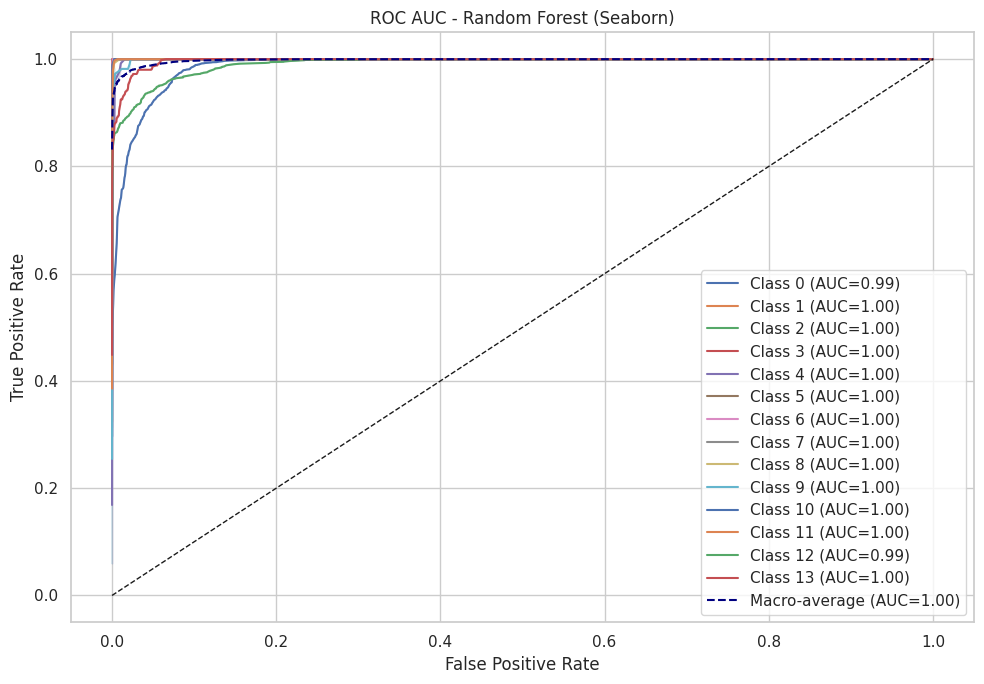

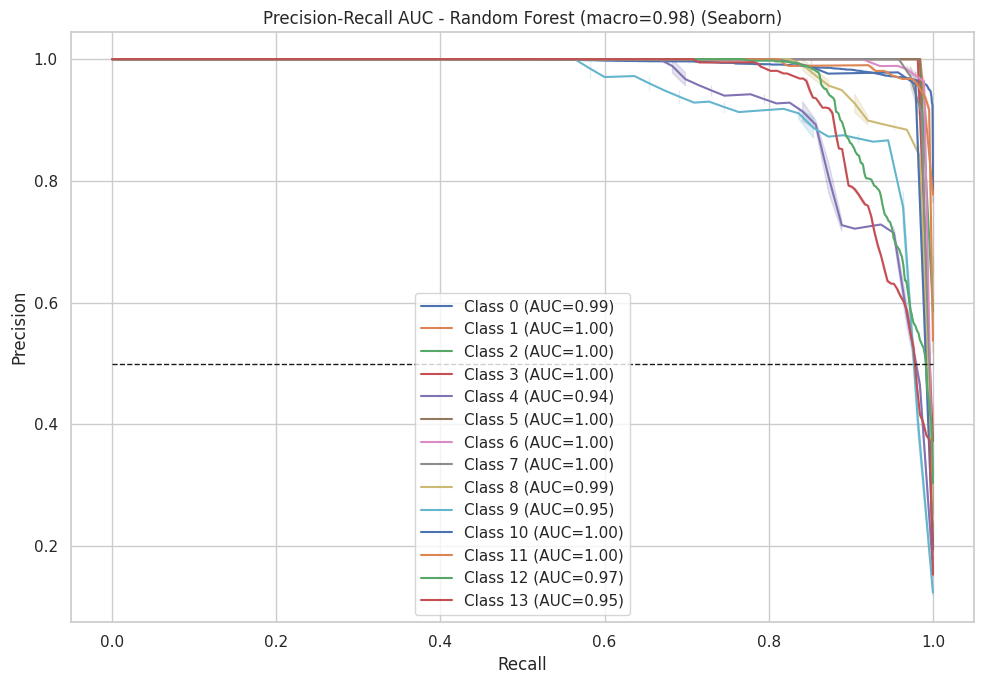

In [32]:
y_score = results["Random Forest"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "Random Forest")
plot_pr_auc_seaborn(y_test_bin, y_score, "Random Forest")

### XGBoost

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)

{'n_estimators': [50, 100], 'max_depth': [3, 6]}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["XGBoost"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 6 candidates, totalling 18 fits


In [34]:
best_model

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


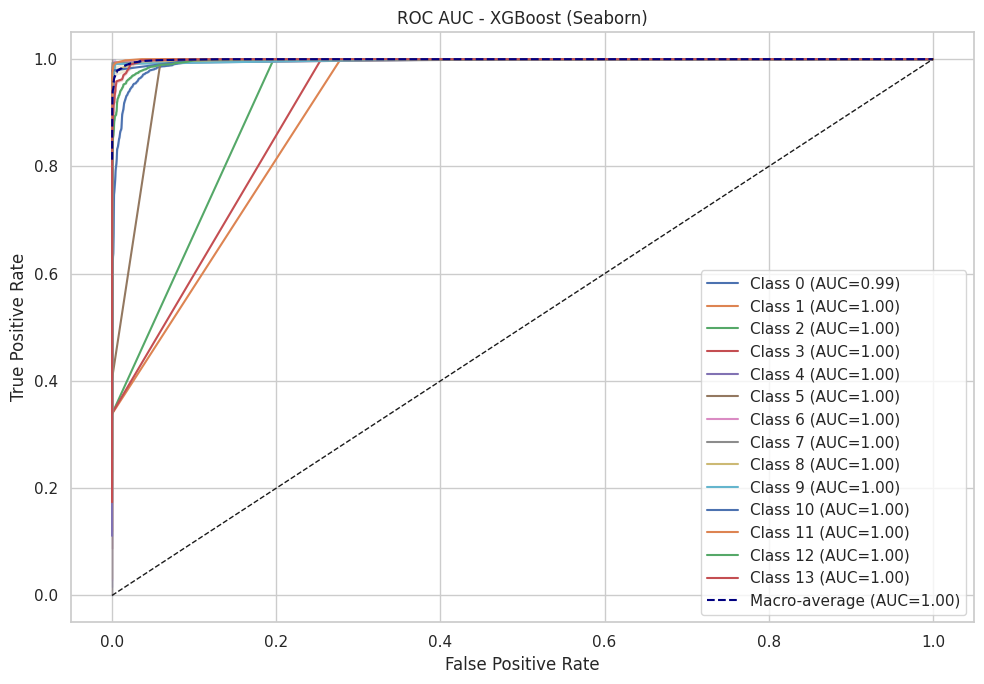

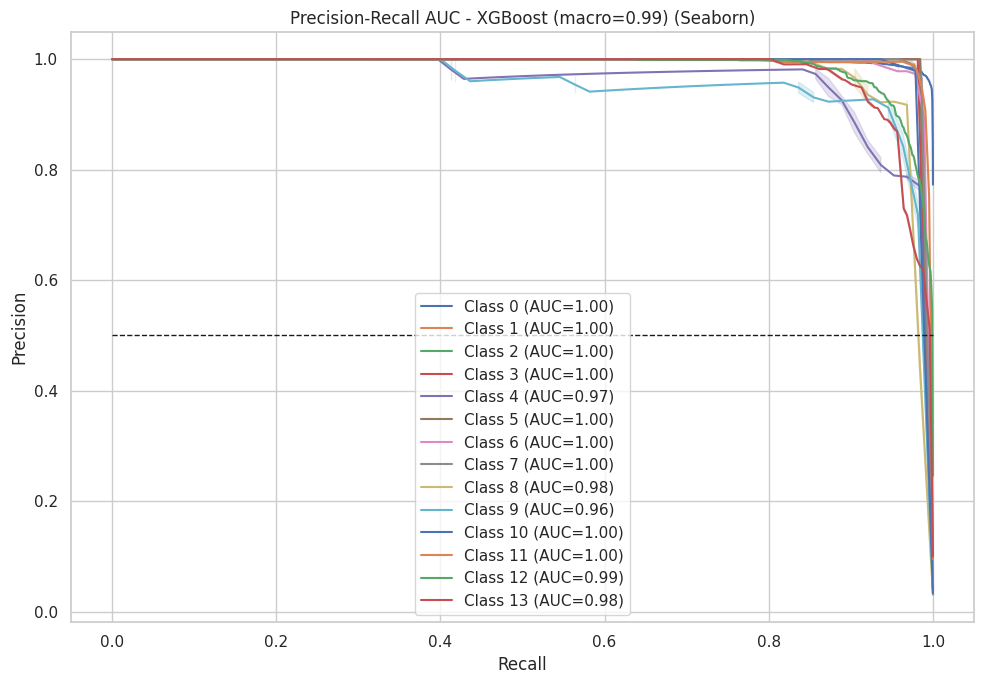

In [35]:
y_score = results["XGBoost"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "XGBoost")
plot_pr_auc_seaborn(y_test_bin, y_score, "XGBoost")